In [118]:
import numpy as np
import scipy
import scipy.integrate
import matplotlib.pyplot as plt
import pyreadr
import pandas as pd
import sympy as sp

#import M2 data
M2 = pyreadr.read_r('/Users/anjalishah/Desktop/Senior_Thesis/full_2018_data_M2_Bering_combined_data.RDS')
M2 = M2[None]

M2=M2.set_index(M2.index.astype(int))
M2

,time_ak,full_O2,full_saturation_O2,full_chla,full_temperature,full_salinity,full_doy,approxPAR,time_gmt,air_tempC,...,cb_mean_tempC_int,t,kz,N,h,do2_dz_at_MLD_smoothed_boosted,doy.y,fmlb_term_mumol_per_kg_per_second,h_smooth_meters,iz
0,2018-05-01 23:00:00,338.542823,93.850346,1.140632,3.707315,32.059670,121.0,NaN,2018-05-02 00:00:00,3.8,...,3.8,NaN,NaN,NaN,NaN,NaN,121,2.510000e-05,16.040017,600.0
1,2018-05-02 00:00:00,340.833953,94.420655,0.528858,3.685249,32.038726,121.0,1035.6077,2018-05-02 01:00:00,4.1,...,3.8,NaN,NaN,NaN,NaN,NaN,121,2.090000e-05,17.333108,600.0
2,2018-05-02 01:00:00,342.079872,94.662048,0.760485,3.644305,32.025575,121.0,1238.0130,2018-05-02 02:00:00,4.1,...,3.8,NaN,NaN,NaN,NaN,NaN,121,1.760000e-05,18.565663,600.0
3,2018-05-02 02:00:00,343.325790,94.903442,0.992112,3.603360,32.012424,121.0,1047.3983,2018-05-02 03:00:00,4.0,...,3.8,NaN,NaN,NaN,NaN,NaN,121,1.490000e-05,19.746918,600.0
4,2018-05-02 03:00:00,344.064635,94.893928,0.956638,3.517202,31.993301,121.0,646.5179,2018-05-02 04:00:00,3.6,...,3.8,NaN,NaN,NaN,NaN,NaN,121,1.270000e-05,20.883307,600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3665,2018-10-01 16:00:00,283.044887,89.094355,3.606080,10.227915,31.844964,274.0,0.0000,2018-10-01 17:00:00,10.7,...,11.7,NaN,NaN,NaN,NaN,NaN,274,1.670000e-07,37.171765,600.0
3666,2018-10-01 17:00:00,283.266056,89.170021,3.766137,10.231230,31.844287,274.0,3.9302,2018-10-01 18:00:00,10.8,...,11.7,NaN,NaN,NaN,NaN,NaN,274,2.550000e-07,37.128667,600.0
3667,2018-10-01 18:00:00,283.487226,89.245686,3.926194,10.234544,31.843611,274.0,82.5342,2018-10-01 19:00:00,10.6,...,11.7,NaN,NaN,NaN,NaN,NaN,274,3.510000e-07,37.084248,600.0
3668,2018-10-01 19:00:00,283.693629,89.316676,3.999519,10.237335,31.844625,274.0,237.7771,2018-10-01 20:00:00,10.6,...,11.7,NaN,NaN,NaN,NaN,NaN,274,4.530000e-07,37.038501,600.0


Text(0, 0.5, 'Temp °C')

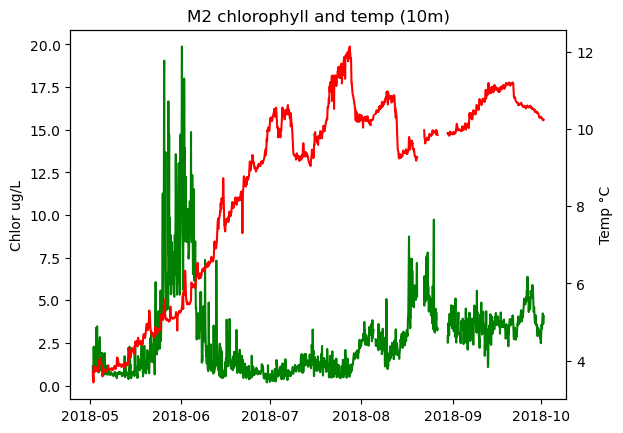

In [119]:
fig, ax1 = plt.subplots()
ax1.plot(M2['time_ak'], M2['full_chla'], color='green')
ax2 = ax1.twinx()
ax2.plot(M2['time_ak'], M2['full_temperature'], color='red')
plt.title('M2 chlorophyll and temp (10m)')
plt.xlabel('Time')
ax1.set_ylabel('Chlor ug/L')
ax2.set_ylabel('Temp °C')

In [190]:
10**-6

1e-06

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_52649/1608690528.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I=(pd.DataFrame((M2['approxPAR'].fillna(method='bfill')) * 10**4)) * 10**-6 #define irradiance function as PAR data from M2, convert to Ein m^2 s^2
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_52649/1608690528.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  T=pd.DataFrame(M2['full_temperature'].fillna(method='bfill')) #define temp function as temp data from M2


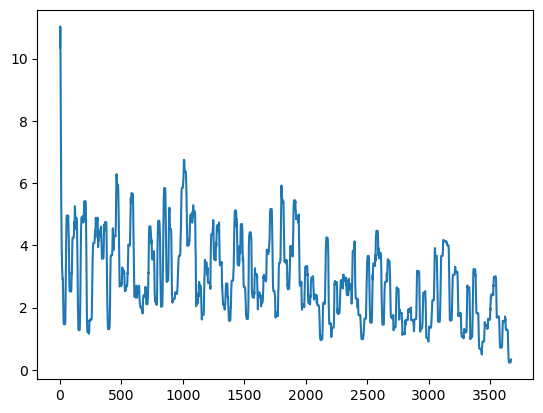

In [198]:
#import, smooth, interpolate: Irradiance, Temperature
time = [0, M2.index[3669]]
time_eval = np.linspace(M2.index[0], M2.index[3669], 3670)

I=(pd.DataFrame((M2['approxPAR'].fillna(method='bfill')) * 10**4)) * 10**-6 #define irradiance function as PAR data from M2, convert to Ein m^2 s^2
I_smoothed= I.rolling(24, min_periods=1).mean()
I_interp = scipy.interpolate.interp1d(time_eval, I_smoothed['approxPAR'], kind='linear', fill_value = 'extrapolate')

T=pd.DataFrame(M2['full_temperature'].fillna(method='bfill')) #define temp function as temp data from M2
T_smoothed= T.rolling(24, min_periods=1).mean()
T_interp = scipy.interpolate.interp1d(time_eval, T_smoothed['full_temperature'], kind='linear', fill_value = 'extrapolate')

plt.plot(I_smoothed)

In [268]:
mu = .06 #phyto max growth rate / hr-1 --> Jin et. al 
r = .0633 #temp coefficient deg-1 -->  Jin et. al 
r_g = .03 #temp coefficient deg-1 -->  Jin et. al 
R_g_0 = 9.23e-4 #max mortality rate at 0 degrees (h-1) -->  Jin et. al 
gamma_D = .006 #(h-1), averaged over: S, L, P (diff zooplankton types) -->  Jin et. al 
gamma_F = .087 #(h-1), averaged over: S, L, P (diff zooplankton types) -->  Jin et. al 
Vmax = 1e-5 #max nitrogen uptake rate (NO3 and NH4) -->  fNO3 in Jin et. al, defined as Vmax in Eslinger et. al ?? confused here... 
fNO3 = .01 #from Jin et. al 
photo_slope = .055 #initial photosynthetic slope -->  Jin et. al 
alpha = .05 # mgC / [mg Chla h W m2] --> Eslinger et. al 
beta = 0 #photoinhibition coefficient mg C /(mg Chla h W m2) --> Eslinger et. al 
P_B_S = 3.25 #max photosynthesis rate, mcgC/(mgChlhr) --> Eslinger et. al 
k_s = 1.0 #MM half staturation constant 



In [270]:
#photosynthetic rate with irradiance -> create dimensionless value to compare with V_Frac

def P_B(I): 
    P_B = P_B_S*(1-(np.exp(-(alpha*I)/P_B_S)))*(np.exp((-beta*I)/P_B_S)) 
    P_frac = P_B/P_B_S
    return P_frac



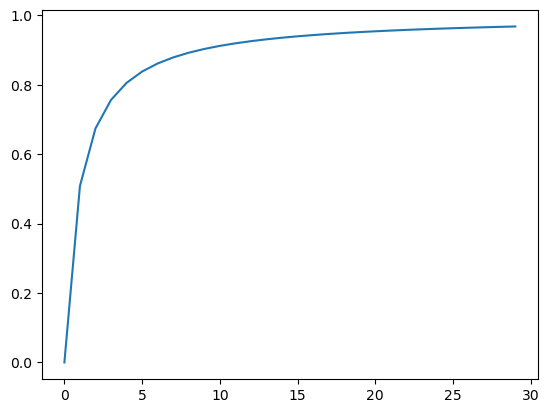

In [269]:
def V_frac(N): #create dimensionless nitrogen value to compare with V_frac
    V_N = Vmax * (N/(N+k_s))
    return V_N / Vmax
N_test = np.linspace(0, 30, 30)

plt.plot(V_frac(N_test))

In [271]:
#define rates function: here flagellate growth rates and diatom growth rates do not differ
def phyto_rates(T, N, I): 
    phyto_growth = mu * np.exp(r*T) * min(N, I) #growth, use minimum of nitrogen and irradiance
    phyto_resp = .05 * mu * np.exp(r*T) #respiration
    phyto_mortality = R_g_0 * np.exp(r_g * T) #mortality
    return [phyto_growth, phyto_resp, phyto_mortality]



In [277]:
#define growth rate function: relates phytoplankton growth rate to temperature 
#define npz system

def npz(t, X): #this model takes in temperature, nutrients (N), and irradiance (I)
    [N, P] = X
    Temp = T_interp(t)
    I_value = I_interp(t)
    PBI = P_B(I_value) #calculate dimensionaless irradiance
    V_frac_calc = V_frac(N)
    [phyto_growth, phyto_resp, phyto_mortality] = phyto_rates(Temp, V_frac_calc, PBI) #calculate phyto rates based on Temperature
    dN_dt = - ((fNO3) * (P*(phyto_growth-phyto_resp))) - ((1-fNO3)*((P*(phyto_growth-phyto_resp)))) #just nitrogen right now
    dP_dt = P*(phyto_growth-phyto_resp-(0.001*phyto_mortality)) #scale by 0.1 to reduce over-grazing
    print(phyto_growth)
    print(dN_dt)
    print(dP_dt)
    print(0.001*phyto_mortality)
    #rho_t[round(t)] = I_value
    return [dN_dt, dP_dt]


In [286]:
#initial condtions 
N0 = 20
P0 = 20

init = [N0, P0]

In [288]:
M2_model = scipy.integrate.solve_ivp(npz, y0 = init, t_span = time, t_eval=time_eval, method='Radau', dense_output=False)

0.010969487151772815
-0.1435200283504577
0.14349939671348785
1.0315818484924527e-06
0.01121045568024166
-0.14990923442821452
0.14988840764727707
1.0310294930960342e-06
0.010969487151772815
-0.1435200283504577
0.14349939671348785
1.0315818484924527e-06
0.010969487151772815
-0.1435200304890728
0.1434993988517955
1.0315818484924527e-06
0.010969487151772815
-0.1435200283504577
0.14349939671348785
1.0315818484924527e-06
0.010969257645810191
-0.14351702559364632
0.14349639416125556
1.0315716195372695e-06
0.010968532532207404
-0.14350753852069664
0.14348690773467904
1.0315393008809198e-06
0.010968007039800933
-0.14350066320519367
0.14348003288761899
1.031515878733312e-06
0.010969257645810191
-0.14354787756254986
0.1435272416950037
1.0315716195372695e-06
0.010968532532207404
-0.14363590097878287
0.14361525173925102
1.0315393008809198e-06
0.010968007039800933
-0.1436997252057581
0.1436790662701116
1.031515878733312e-06
0.010968007039800933
-0.14369972519334265
0.14367906625769794
1.031515878733

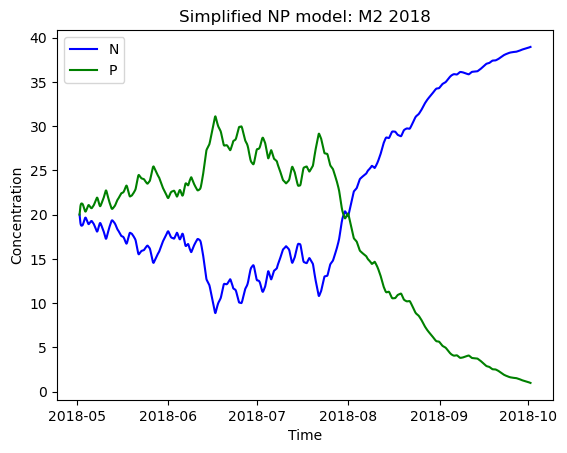

In [290]:
timestamp = M2['time_ak']
plt.plot(timestamp, M2_model.y[0], color='blue') #N
plt.plot(timestamp, M2_model.y[1], color='green') #P

plt.title('Simplified NP model: M2 2018')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend(['N', 'P'])

In [233]:
(V_frac(20))

0.9523809523809524

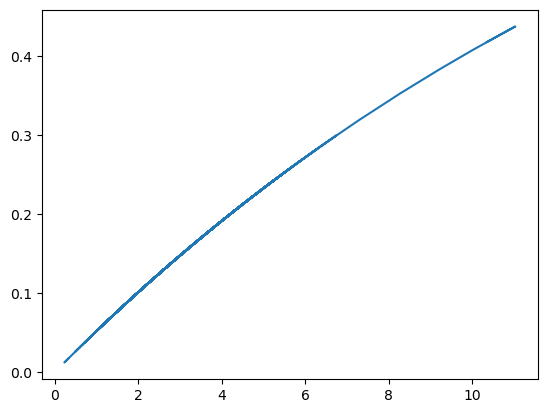

In [200]:
plt.plot(I_smoothed, P_B(I_smoothed))



In [208]:
P = P_B(I_smoothed)
P = P.set_index(I_smoothed)
P['approxPAR'][0] - P['approxPAR'][1] 

,approxPAR
0,0.417817
1,0.417817
2,0.437295
3,0.433339
4,0.407412
...,...
3665,0.012540
3666,0.012540
3667,0.013967
3668,0.017286
